## Bootstrap

Kernel must be `backend/.venv` (VSCode: *Select Kernel* → Python Environments → `backend/.venv/bin/python`).

Three things this cell handles:

1. `backend/app/` goes on `sys.path`, **not** `backend/`. The app has no top-level
   `__init__.py` and imports itself flat (`from config import settings`,
   `from db.session import ...`), matching how `fastapi run app/main.py` starts it.
2. `.env` loads **before** any app import — `app/config.py` runs `settings = Settings()`
   at module scope, so a missing `REDIS_URL`/`INTERNAL_API_TOKEN` raises on import.
3. `POSTGRES_HOST` is overridden to `localhost`. `.env` sets it to `db`, the container
   service name, which only resolves inside the container network; the kernel runs on
   the host, so leaving it alone fails with `gaierror` on the first query. The override
   has to happen before `db.session` is imported — that module builds the engine at
   import time.

Re-run this cell after a kernel restart, and restart the kernel if you've already
imported `db.session` in this session — the engine is built once and holds the old host.

In [1]:
import os
import sys
from pathlib import Path

from dotenv import load_dotenv

ROOT = Path.cwd().parent  # notebooks/ -> watson/
APP = ROOT / "backend" / "app"

load_dotenv(
    ROOT / ".env"
)  # before app imports: config.py instantiates Settings() at import
os.environ["POSTGRES_HOST"] = (
    "localhost"  # kernel is on the host, where `db` doesn't resolve
)
if str(APP) not in sys.path:
    sys.path.insert(0, str(APP))

%load_ext autoreload
%autoreload 2

## Importing app modules

Paths are relative to `backend/app/`, so drop the `app.` prefix.

In [2]:
from config import settings
from db.models import Transaction
from db.session import async_session_maker, sync_session_manager
import logfire

logfire.configure(
    token=settings.LOGFIRE_TOKEN,
    send_to_logfire="if-token-present",
    environment=settings.APP_ENV,
    scrubbing=False,
    service_name="watson",
    distributed_tracing=True,
)

logfire.instrument_pydantic_ai()
logfire.instrument_httpx()
logfire.instrument_openai()


settings.PROJECT_NAME, settings.POSTGRES_DB

('Watson', 'postgres')

Logfire project URL: https://logfire-us.pydantic.dev/suban244/watson


## Querying

ipykernel allows top-level `await`, so the app's async session works as-is.

In [5]:
from sqlalchemy import select

async with async_session_maker() as session:
    result = await session.scalars(
        select(Transaction).order_by(Transaction.date.desc()).limit(5)
    )
    rows = result.all()

[(t.title, t.amount) for t in rows]

[('Travel to Dharan', 3000.0),
 ('Turtle food', 300.0),
 ('Turtle food', 300.0),
 ('Momos, office lunch', 180.0),
 ('grab stuff', 5000.0)]

In [6]:
# Sync alternative (the one the taskiq worker uses)
with sync_session_manager() as session:
    rows = session.scalars(select(Transaction).limit(5)).all()

[(t.title, t.amount) for t in rows]

[('Dental cleaning appointment', 388.85),
 ('evening food', 500.0),
 ('evening food', 400.0),
 ('2 buff momo and dahi', 540.0),
 ('Grocery shopping at Whole Foods', 370.69)]

## Plotting

`run_code` is Monty, not CPython — a subset interpreter whose entire import surface is
`sys`, `typing`, `asyncio`, `math`, `json`, `re`, `unicodedata`, `datetime`, `os` and
`pathlib`. `import matplotlib` inside the sandbox raises `ModuleNotFoundError`, and so
does `numpy`.

So matplotlib stays on the host and the agent reaches it the same way it reaches the
database: as a tool. The model writes the SQL and shapes the rows into labels and
series inside the sandbox, then calls `plot_chart` with plain data. Rendering happens
here, where it is deterministic and a hallucinated path can't reach `savefig`.

`plot_chart` returns a short receipt rather than the image — the PNG lands in `CHARTS`
for the next cell to display. Sending the image back through the sandbox would work
(`BinaryContent` survives the round trip) but costs vision tokens on every turn, and
in the bot the picture needs to reach Discord, not the model.

In [7]:
import asyncio
import io
from typing import Literal

import matplotlib

matplotlib.use("Agg")  # headless: the kernel has no display, and neither does the Pi

import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# Categorical hues in fixed order, never cycled: a series keeps its colour as the
# data behind it changes. Adjacent pairs stay separable for colourblind readers.
SERIES_COLORS = [
    "#2a78d6",  # blue
    "#eb6834",  # orange
    "#1baf7a",  # aqua
    "#eda100",  # yellow
    "#e87ba4",  # magenta
    "#008300",  # green
    "#4a3aa7",  # violet
    "#e34948",  # red
]
SURFACE, INK, MUTED, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#e3e2dd"


def _npr(x: float, _pos: int = 0) -> str:
    """10868.64 -> '10.9k'. One decimal, or neighbouring ticks both collapse to '6k'."""
    if abs(x) >= 1000:
        return f"{x / 1000:,.1f}k".replace(".0k", "k")
    return f"{x:,.0f}"


def render_chart(
    kind: Literal["bar", "line", "stacked_bar"],
    labels: list[str],
    series: dict[str, list[float]],
    title: str = "",
    value_label: str = "NPR",
) -> bytes:
    """Draw one chart and return it as PNG bytes. Pure function, no I/O."""
    if not labels or not series:
        raise ValueError("labels and series must both be non-empty")
    for name, values in series.items():
        if len(values) != len(labels):
            raise ValueError(
                f"series {name!r} has {len(values)} values but there are {len(labels)} labels"
            )
    if len(series) > len(SERIES_COLORS):
        # A 9th series would have to reuse a colour, which makes the legend a lie.
        raise ValueError(
            f"at most {len(SERIES_COLORS)} series in one chart; split them across two charts"
        )

    fig, ax = plt.subplots(figsize=(7.5, 4.2), dpi=140)
    fig.patch.set_facecolor(SURFACE)
    ax.set_facecolor(SURFACE)

    names = list(series)
    if kind == "bar":
        # Horizontal, so category names read straight instead of rotated 45°.
        y = list(range(len(labels)))
        if len(names) == 1:
            ax.barh(y, series[names[0]], height=0.62, color=SERIES_COLORS[0])
            for i, v in zip(y, series[names[0]]):  # direct labels: no legend needed
                ax.text(
                    v, i, f" {_npr(v)}", va="center", ha="left", color=MUTED, fontsize=8
                )
        else:
            h = 0.8 / len(names)
            for s, name in enumerate(names):
                offsets = [i + (s - (len(names) - 1) / 2) * h for i in y]
                ax.barh(
                    offsets,
                    series[name],
                    height=h * 0.9,
                    color=SERIES_COLORS[s],
                    label=name,
                )
        ax.set_yticks(y, labels, color=INK, fontsize=9)
        ax.invert_yaxis()  # largest at the top, reading order
        ax.xaxis.set_major_formatter(FuncFormatter(_npr))
        ax.grid(axis="x", color=GRID, linewidth=0.8)
    elif kind == "stacked_bar":
        bottom = [0.0] * len(labels)
        for s, name in enumerate(names):
            ax.bar(
                labels,
                series[name],
                bottom=bottom,
                color=SERIES_COLORS[s],
                label=name,
                width=0.62,
                linewidth=1.5,
                edgecolor=SURFACE,  # a hairline of surface between segments
            )
            bottom = [b + v for b, v in zip(bottom, series[name])]
        ax.yaxis.set_major_formatter(FuncFormatter(_npr))
        ax.grid(axis="y", color=GRID, linewidth=0.8)
    else:  # line
        for s, name in enumerate(names):
            ax.plot(
                labels,
                series[name],
                color=SERIES_COLORS[s],
                linewidth=2,
                marker="o",
                markersize=4,
                label=name,
            )
        ax.yaxis.set_major_formatter(FuncFormatter(_npr))
        ax.grid(axis="y", color=GRID, linewidth=0.8)

    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["bottom" if kind == "bar" else "left"].set_visible(False)
    for side in ("bottom", "left"):
        ax.spines[side].set_color(GRID)
    ax.tick_params(colors=MUTED, labelsize=9, length=0)
    if title:
        # The model often writes the unit into the title itself; only add it when
        # it didn't, or the heading reads "... (NPR)  (NPR)".
        unit = value_label and value_label.lower() not in title.lower()
        ax.set_title(
            f"{title}  ({value_label})" if unit else title,
            color=INK,
            fontsize=11,
            loc="left",
            pad=12,
        )
    if len(names) > 1:  # one series needs no legend — the title names it
        ax.legend(frameon=False, fontsize=9, labelcolor=MUTED, loc="best")

    buf = io.BytesIO()
    fig.savefig(buf, format="png", bbox_inches="tight", facecolor=SURFACE)
    plt.close(fig)  # a figure leaked per chart is a memory leak on a 2GB Pi
    return buf.getvalue()


CHARTS: list[bytes] = []  # the model gets a receipt; the PNG lands here


async def plot_chart(
    kind: Literal["bar", "line", "stacked_bar"],
    labels: list[str],
    series: dict[str, list[float]],
    title: str = "",
) -> str:
    """Render a chart from data you have already fetched, and show it to the user.

    `labels` are the entries along the axis — the categories, months or days you
    are charting. `series` maps a name to one value per label, so every list is
    exactly as long as `labels`; each entry is drawn in its own colour and named
    in the legend. Most charts need only one:

        plot_chart("bar", ["food", "transport"], {"Spend": [10868.6, 5843.0]},
                   title="Expenses by category")
        plot_chart("line", ["Jun", "Jul", "Aug"],
                   {"Food": [4100, 3800, 4300], "Transport": [1100, 1700, 1400]},
                   title="Monthly spend")

    Use "bar" to compare categories, "line" for change over time, "stacked_bar"
    for parts of a total over time. Amounts are NPR — say so in `title` only if
    it matters; the chart labels the unit itself.

    Chart every row the user asked about: `labels` has no limit, so all 14
    categories go in one call. Only `series` is capped, at 8 — past that make a
    second chart rather than leaving any out.

    Returns a short confirmation, not the image: the user sees the chart, you do not.
    """
    try:
        # to_thread: a render is ~200ms of blocking CPU, and in the bot this runs
        # on the same event loop that is serving Discord.
        png = await asyncio.to_thread(render_chart, kind, labels, series, title)
    except ValueError as e:
        return f"chart not rendered: {e}"
    CHARTS.append(png)
    return f"chart shown to the user ({kind}, {len(series)} series over {len(labels)} labels)"

In [8]:
from bot.agent.watson import make_model
from psycopg.rows import dict_row
from pydantic_ai import Agent
from pydantic_ai_harness import CodeMode
from db.readonly import async_readonly_connection
from typing import Any


async def query_database_function(query: str) -> str:
    try:
        async with async_readonly_connection() as conn:
            async with conn.cursor(row_factory=dict_row) as cursor:
                await cursor.execute(query)  # type: ignore[arg-type]
                return str(await cursor.fetchall())
    except Exception as e:
        return str(e)


agent = Agent(
    model=make_model(),
    instructions=(
        "You are a helpful assistant that can answer questions about the user's "
        "finances. Amounts are NPR. When the user asks to see, plot, chart or "
        "visualise something, query the data first and then call `plot_chart` "
        "with it; keep the accompanying text short, since they can see the chart."
    ),
    capabilities=[CodeMode()],  # tools='all': both functions become sandbox callables
    tools=[query_database_function, plot_chart],
)

In [7]:
await agent.run(
    "tell me expenses per category, usue query database function (see schema first)"
)

20:40:58.263 agent run
20:40:58.274   chat openai/gpt-5.6-luna
20:40:58.279     Chat Completion with 'openai/gpt-5.6-luna' [LLM]
20:41:01.143   running tool: run_code
20:41:01.209     running tool: query_database_function
20:41:01.235   chat openai/gpt-5.6-luna
20:41:01.236     Chat Completion with 'openai/gpt-5.6-luna' [LLM]
20:41:03.923   running tool: run_code
20:41:03.924     running tool: query_database_function
20:41:03.956   chat openai/gpt-5.6-luna
20:41:03.958     Chat Completion with 'openai/gpt-5.6-luna' [LLM]
20:41:06.303   running tool: run_code
20:41:06.305     running tool: query_database_function
20:41:06.332   chat openai/gpt-5.6-luna
20:41:06.336     Chat Completion with 'openai/gpt-5.6-luna' [LLM]
20:41:08.761   running tool: run_code
20:41:08.776   chat openai/gpt-5.6-luna
20:41:08.779     Chat Completion with 'openai/gpt-5.6-luna' [LLM]


AgentRunResult(output='Expenses by category (all recorded expense transactions):\n\n| Category | Total |\n|---|---:|\n| Food | NPR 10,868.64 |\n| Other | NPR 9,951.41 |\n| Health | NPR 6,626.49 |\n| Entertainment | NPR 6,259.92 |\n| Shopping | NPR 5,967.67 |\n| Transport | NPR 5,842.97 |\n| Dining out | NPR 5,720.00 |\n| Utilities | NPR 5,145.34 |\n| Travel | NPR 4,856.53 |\n| Long travel | NPR 3,000.00 |\n| Miscellaneous | NPR 1,200.00 |\n| Snacks | NPR 589.93 |\n| Household | NPR 300.00 |\n| Groceries | NPR 30.00 |')

20:41:59.281 agent run
20:41:59.286   chat openai/gpt-5.6-luna
20:41:59.287     Chat Completion with 'openai/gpt-5.6-luna' [LLM]
20:42:02.516   running tool: run_code
20:42:02.589     running tool: query_database_function
20:42:02.627   chat openai/gpt-5.6-luna
20:42:02.629     Chat Completion with 'openai/gpt-5.6-luna' [LLM]
20:42:04.227   running tool: run_code
20:42:04.228     running tool: query_database_function
20:42:04.250   chat openai/gpt-5.6-luna
20:42:04.252     Chat Completion with 'openai/gpt-5.6-luna' [LLM]
20:42:06.425   running tool: run_code
20:42:06.426     running tool: query_database_function
20:42:06.470   chat openai/gpt-5.6-luna
20:42:06.473     Chat Completion with 'openai/gpt-5.6-luna' [LLM]
20:42:08.110   running tool: run_code
20:42:08.111     running tool: query_database_function
20:42:08.131   chat openai/gpt-5.6-luna
20:42:08.133     Chat Completion with 'openai/gpt-5.6-luna' [LLM]
20:42:11.688   running tool: run_code
20:42:11.690     running tool: plot_c

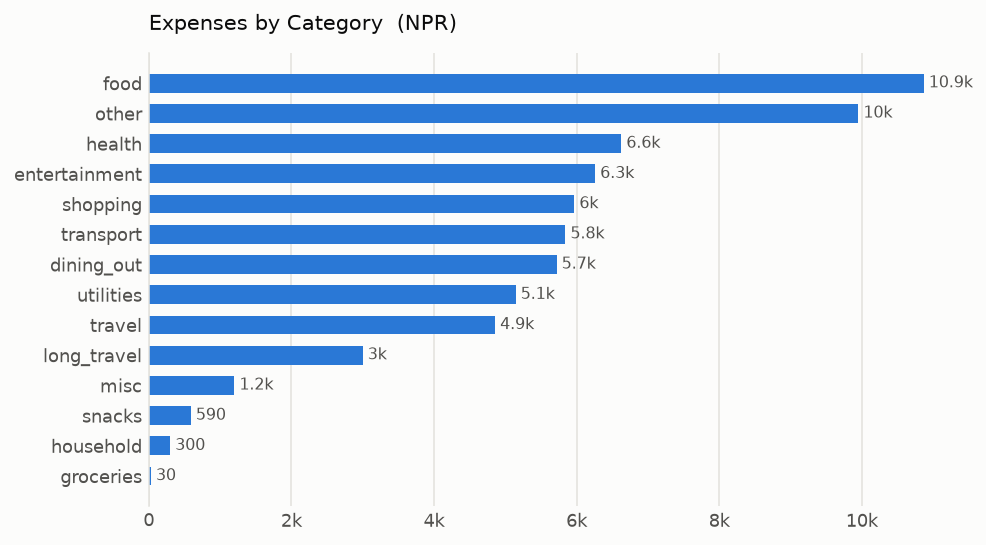

'Your expenses by category are shown in the chart above. Total expenses: **NPR 76,359.88**.'

In [9]:
from IPython.display import Image, display

CHARTS.clear()
result = await agent.run("chart my expenses per category")

for png in CHARTS:
    display(Image(png))
result.output

## Alternative: Vega-Lite specs

`plot_chart` trades flexibility for safety — the model picks one of three shapes
and fills in the numbers. The other way round is to let it write the whole chart
as a **Vega-Lite spec**: still declarative JSON rather than code, but it can
layer, facet, annotate and draw rules without a new tool per shape.

`vl-convert` rasterises the spec in Rust — no browser, no numpy, no pandas, and a
33MB aarch64 wheel for the Pi. Plotly's static export needs a real Chrome
(kaleido 1.x depends on `choreographer`), which is why it isn't here.

Two things stay host-side: the theme, merged *over* whatever the model sends so
it can't pick its own colours, and a check that the data is inline — a `data.url`
would have the renderer fetch from the network.

In [9]:
import json

import vl_convert as vlc

# Merged over the model's spec, never under it: the model chooses marks and
# encodings, the palette and type stay ours.
VEGA_THEME: dict[str, Any] = {
    "background": SURFACE,
    "font": "Helvetica Neue, Helvetica, DejaVu Sans, sans-serif",
    "view": {"stroke": None},
    "axis": {
        "labelColor": MUTED,
        "titleColor": MUTED,
        "labelFontSize": 11,
        "titleFontSize": 11,
        "domain": False,
        "ticks": False,
        "gridColor": GRID,
        "gridWidth": 0.8,
    },
    "title": {
        "color": INK,
        "fontSize": 15,
        "anchor": "start",
        "subtitleColor": MUTED,
        "subtitleFontSize": 11,
        "offset": 12,
    },
    "legend": {
        "labelColor": MUTED,
        "titleColor": MUTED,
        "labelFontSize": 11,
        "symbolType": "circle",
    },
    "range": {"category": SERIES_COLORS},
    "bar": {"color": SERIES_COLORS[0], "cornerRadiusEnd": 4},
    "line": {"strokeWidth": 2},
    "point": {"filled": True, "size": 40},
    "text": {"color": MUTED, "fontSize": 10},
}


def render_spec(spec: dict[str, Any]) -> bytes:
    """Theme a Vega-Lite spec and rasterise it. Raises on an invalid spec."""
    data = spec.get("data")
    if isinstance(data, dict) and "url" in data:
        # vl-convert would happily fetch it; the model has no business naming hosts.
        raise ValueError("inline data only: put the rows in data.values, not data.url")

    full = {"$schema": "https://vega.github.io/schema/vega-lite/v5.json", **spec}
    full["config"] = {**spec.get("config", {}), **VEGA_THEME}
    # Only unit and layer specs take a top-level width; facet/concat reject it.
    if "width" not in full and ("mark" in full or "layer" in full):
        full["width"] = 620

    return vlc.vegalite_to_png(json.dumps(full), scale=2)


async def plot_spec(spec: dict[str, Any]) -> str:
    """Render a Vega-Lite v5 spec and show the chart to the user.

    Put the rows inline under `data.values` as a list of records — never a url —
    and encode them with `mark` plus `encoding`, e.g.

        plot_spec({
            "title": {"text": "Expenses by category", "subtitle": "NPR"},
            "data": {"values": [{"category": "food", "amount": 10868.6},
                                {"category": "transport", "amount": 5843.0}]},
            "mark": "bar",
            "encoding": {
                "y": {"field": "category", "type": "nominal", "sort": "-x", "title": None},
                "x": {"field": "amount", "type": "quantitative", "title": None},
            },
        })

    Layer, facet, `rule` marks for averages or budgets, and `text` marks for
    direct labels are all available — use them when they make the answer clearer.
    Amounts are NPR. Leave colours, fonts and axis styling alone: a house theme is
    merged in afterwards and overrides anything you set in `config`.

    Returns a short confirmation, not the image: the user sees the chart, you do not.
    """
    try:
        png = await asyncio.to_thread(render_spec, spec)
    except (
        Exception
    ) as e:  # invalid spec: hand the message back so the model can fix it
        return f"chart not rendered: {e}"
    CHARTS.append(png)
    return f"chart shown to the user ({len(png) // 1024} KB PNG)"


vega_agent = Agent(
    model=make_model(),
    instructions=(
        "You are a helpful assistant that can answer questions about the user's "
        "finances. Amounts are NPR. When the user asks to see, plot, chart or "
        "visualise something, query the data first and then call `plot_spec` "
        "with a Vega-Lite spec built from it; keep the accompanying text short, "
        "since they can see the chart."
    ),
    capabilities=[CodeMode()],
    tools=[query_database_function, plot_spec],
)

21:01:55.905 vega_agent run
21:01:55.916   chat openai/gpt-5.6-luna
21:01:55.917     Chat Completion with 'openai/gpt-5.6-luna' [LLM]
21:01:58.800   running tool: run_code
21:01:58.875     running tool: query_database_function
21:01:58.911   chat openai/gpt-5.6-luna
21:01:58.912     Chat Completion with 'openai/gpt-5.6-luna' [LLM]
21:02:01.001   running tool: run_code
21:02:01.002     running tool: query_database_function
21:02:01.030   chat openai/gpt-5.6-luna
21:02:01.032     Chat Completion with 'openai/gpt-5.6-luna' [LLM]
21:02:03.386   running tool: run_code
21:02:03.387     running tool: query_database_function
21:02:03.410   chat openai/gpt-5.6-luna
21:02:03.413     Chat Completion with 'openai/gpt-5.6-luna' [LLM]
21:02:04.828   running tool: run_code
21:02:04.829     running tool: query_database_function
21:02:04.848   chat openai/gpt-5.6-luna
21:02:04.850     Chat Completion with 'openai/gpt-5.6-luna' [LLM]
21:02:08.465   running tool: run_code
21:02:08.471     running tool: p

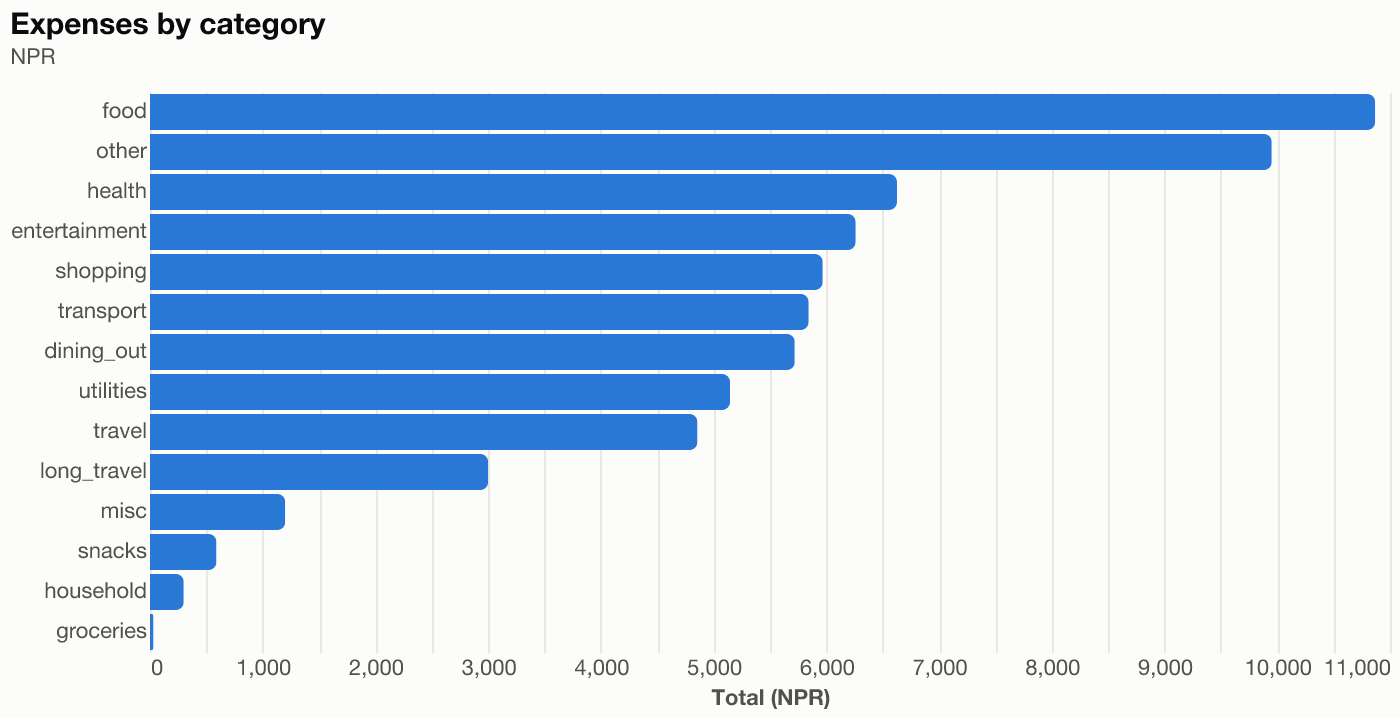

'Here’s your expense breakdown by category.'

In [13]:
from IPython.display import Image, display

CHARTS = []  # the model gets a receipt; the PNG lands here

CHARTS.clear()
result = await vega_agent.run("chart my expenses per category")

for png in CHARTS:
    display(Image(png))
result.output